### Load libraries

In [32]:
from importlib import reload
from helpers import *
from helpers.portfolio import *
import pandas as pd

from helpers.clustering import cluster_select_representatives_from_csv, visualize_clusters
from helpers.fetch import load_data
import pandas as pd

### Clustering

Found 68 tickers across 10 clusters


/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/giacomomaggiore/Desktop/coding/leverage-api-api/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


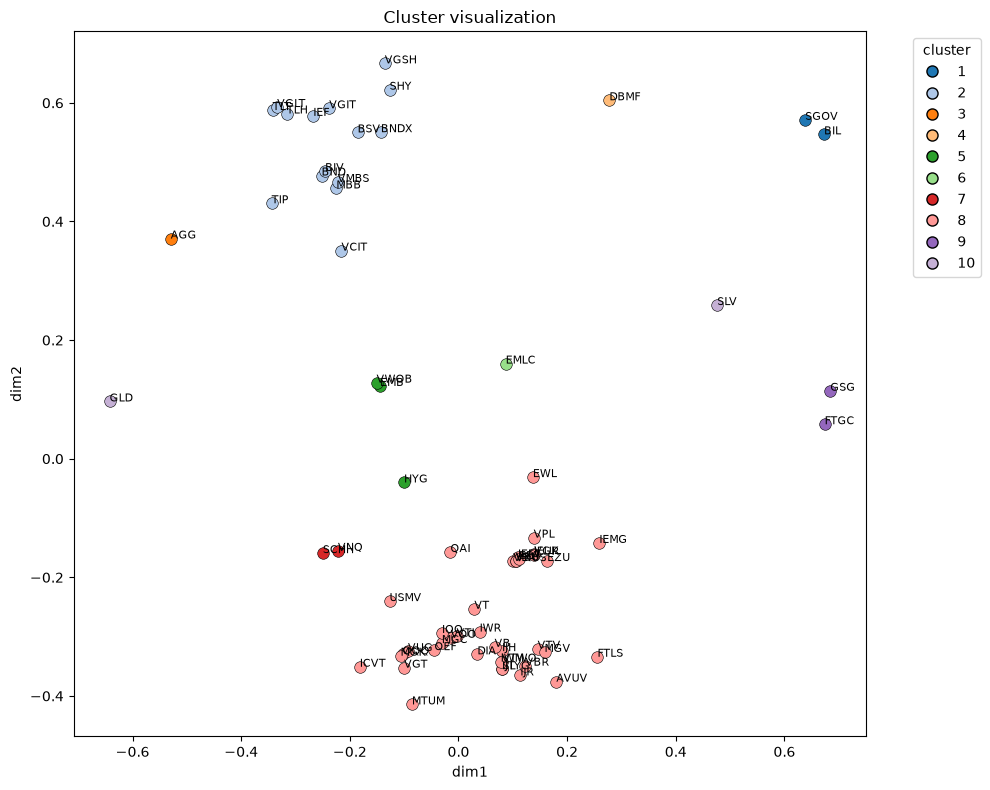

In [33]:
ETF_UNIVERSE_CSV_PATH = "data/etf_universe.csv"

# get clusters (and representatives) from the universe CSV
selected_tickers, clusters = cluster_select_representatives_from_csv(ETF_UNIVERSE_CSV_PATH, n_clusters=10)

print('Found', sum(len(v) for v in clusters.values()), 'tickers across', len(clusters), 'clusters')

# Build aligned price matrix for all tickers in the clusters (inner join on dates)
tickers = sorted([t for members in clusters.values() for t in members])
start_date = '2012-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
prices = pd.concat([load_data(t, start_date, end_date)['adj close'].rename(t) for t in tickers], axis=1, join='inner')
returns = prices.pct_change().dropna()

# Visualize clusters using the returns correlation (MDS embedding)
fig, ax = visualize_clusters(clusters, returns=returns)


### Common window / Optimization / Portfolio construction

In [ ]:
# common window for selected_tickers tickers

min_window, max_window = common_window(selected_tickers)

start_date = "2012-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

print("Min common start date:", min_window, "Max common end date:", max_window)
    
portfolios = build_portfolios(selected_tickers, start_date, end_date)


Min common start date: 2020-06-01 00:00:00 Max common end date: 2026-07-08 00:00:00


dict_keys(['min_variance', 'max_sharpe', 'market_cap'])

## Backtest with historical data

In [ ]:
# Backtest with historical data (min-variance, max-sharpe, market-cap (VT), equal-weight)
from helpers.backtest import backtest_portfolio

# If equal_weight is missing (e.g., built before helper update), create 1/N weights over current tickers
if "equal_weight" not in portfolios:
    cols = list(portfolios["min_variance"].columns)
    if len(cols) == 0:
        raise ValueError("No tickers found to build equal_weight.")
    # single-row equal-weight, then forward-fill across the date index of min_variance
    ew_row = pd.Series({t: 1.0 / len(cols) for t in cols})
    ew = pd.DataFrame([ew_row], columns=cols)
    ew.index = [portfolios["min_variance"].index.min()]
    ew = ew.reindex(portfolios["min_variance"].index, method="ffill")
    portfolios["equal_weight"] = ew

# compute portfolio value series for each strategy
min_variance = backtest_portfolio(portfolios["min_variance"], start_value=10_000.0)
max_sharpe  = backtest_portfolio(portfolios["max_sharpe"],  start_value=10_000.0)
market_cap  = backtest_portfolio(portfolios["market_cap"],  start_value=10_000.0)
equal_weight = backtest_portfolio(portfolios["equal_weight"], start_value=10_000.0)

# merge into a single DataFrame for comparison
backtest_results = pd.concat(
    [
        min_variance.rename("min_variance"),
        max_sharpe.rename("max_sharpe"),
        market_cap.rename("market_cap"),
        equal_weight.rename("equal_weight"),
    ],
    axis=1,
)
backtest_results

,min_variance,max_sharpe,market_cap,equal_weight
date,,,,
2020-06-02,10007.654616,9965.903110,10000.0,10043.672465
2020-06-03,9972.205944,9849.061969,10000.0,10067.319026
2020-06-04,9951.057017,9898.893441,10000.0,10056.991575
2020-06-05,9955.553501,9784.253726,10000.0,10143.005288
2020-06-08,9976.265764,9851.946283,10000.0,10187.299580
...,...,...,...,...
2026-04-17,11796.650054,15686.573097,10000.0,16563.306344
2026-04-20,11799.596964,15686.420745,10000.0,16591.318498
2026-07-06,11849.313307,15726.794130,10000.0,16380.659779


## Montecarlo Parametric

In [ ]:
# Monte Carlo (parametric): simulate returns, rebuild weights, backtest
from helpers.montecarlo import simulate_parametric, rebalance_on_simulation

# simulate ~1 year of daily returns for current tickers
tickers = list(portfolios["min_variance"].columns)
sims_param = simulate_parametric(tickers, n_days=252, n_sims=1, lookback_years=3, seed=42)

# rebuild weights on simulated prices and backtest
W_param, V_param = rebalance_on_simulation(
    sims_param[0], lookback_years=4, freq="BMS", which="min_variance", start_value=10_000.0
)
V_param.tail()

,VOO,DBMF,HYG,EMLC,BND,AGG,SGOV,GLD,GSG,VNQ
2016-01-01,0.05659,0.00000,0.09487,0.0,0.45785,0.37329,0.00000,0.0,0.01739,0.0
2016-01-04,0.05659,0.00000,0.09487,0.0,0.45785,0.37329,0.00000,0.0,0.01739,0.0
2016-01-05,0.05659,0.00000,0.09487,0.0,0.45785,0.37329,0.00000,0.0,0.01739,0.0
2016-01-06,0.05659,0.00000,0.09487,0.0,0.45785,0.37329,0.00000,0.0,0.01739,0.0
2016-01-07,0.05659,0.00000,0.09487,0.0,0.45785,0.37329,0.00000,0.0,0.01739,0.0
...,...,...,...,...,...,...,...,...,...,...
2026-07-02,0.00000,0.02221,0.00883,0.0,0.03064,0.01807,0.91797,0.0,0.00228,0.0
2026-07-03,0.00000,0.02221,0.00883,0.0,0.03064,0.01807,0.91797,0.0,0.00228,0.0
2026-07-06,0.00000,0.02221,0.00883,0.0,0.03064,0.01807,0.91797,0.0,0.00228,0.0
2026-07-07,0.00000,0.02221,0.00883,0.0,0.03064,0.01807,0.91797,0.0,0.00228,0.0


## Montecarlo Bootstrap

In [ ]:
# Monte Carlo (bootstrap): moving-block bootstrap, rebuild weights, backtest
from helpers.montecarlo import simulate_bootstrap, rebalance_on_simulation

sims_boot = simulate_bootstrap(
    tickers, n_days=252, n_sims=1, lookback_years=3, block_size=10, seed=1
)
W_boot, V_boot = rebalance_on_simulation(
    sims_boot[0], lookback_years=4, freq="BMS", which="min_variance", start_value=10_000.0
)
V_boot.tail()

[Docs](https://pyportfolioopt.readthedocs.io/en/stable/index.html)

### Optimization Notes (PyPortfolioOpt)

- Expected returns use PyPortfolioOpt's `mean_historical_return` on adjusted-close prices (simple returns, annualized).
- Covariance is estimated from returns via PyPortfolioOpt risk models (`sample_cov`, Ledoit–Wolf, OAS, or EWMA depending on `cov_method`).
- Optimizers: `EfficientFrontier.min_volatility()` for min-variance and `EfficientFrontier.max_sharpe(risk_free_rate=rf)` for max-Sharpe.
- Long-only and fully invested constraints are enforced by default.

In [ ]:

portfolios
# portfolios["min_variance"], portfolios["max_sharpe"], portfolios["market_cap"]
# each is a DataFrame: index=business days, columns=tickers, values=weights


NameError: name 'interest_tickers' is not defined

In [ ]:
portfolios["min_variance"]

,SPY,QQQ,VT,VEA,VGSH,IEF,VGLT,GLD,TLH,BTC=F,AAPL,TSLA
2016-01-01,0.02801,0.0,0.0,0.0,0.95701,0.01373,0.0,0.0,0.0,0.0,0.00124,0.0
2016-01-04,0.02801,0.0,0.0,0.0,0.95701,0.01373,0.0,0.0,0.0,0.0,0.00124,0.0
2016-01-05,0.02801,0.0,0.0,0.0,0.95701,0.01373,0.0,0.0,0.0,0.0,0.00124,0.0
2016-01-06,0.02801,0.0,0.0,0.0,0.95701,0.01373,0.0,0.0,0.0,0.0,0.00124,0.0
2016-01-07,0.02801,0.0,0.0,0.0,0.95701,0.01373,0.0,0.0,0.0,0.0,0.00124,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-29,0.02438,0.0,0.0,0.0,0.97562,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0
2026-06-30,0.02438,0.0,0.0,0.0,0.97562,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0
2026-07-01,0.02829,0.0,0.0,0.0,0.97171,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0
2026-07-02,0.02829,0.0,0.0,0.0,0.97171,0.00000,0.0,0.0,0.0,0.0,0.00000,0.0


In [ ]:
portfolios["max_sharpe"]

,SPY,QQQ,VT,VEA,VGSH,IEF,VGLT,GLD,TLH,BTC=F,AAPL,TSLA
2016-01-01,0.03352,0.22295,0.0,0.0,0.33056,0.0,0.0,0.00000,0.35696,0.00000,0.0,0.05602
2016-01-04,0.03352,0.22295,0.0,0.0,0.33056,0.0,0.0,0.00000,0.35696,0.00000,0.0,0.05602
2016-01-05,0.03352,0.22295,0.0,0.0,0.33056,0.0,0.0,0.00000,0.35696,0.00000,0.0,0.05602
2016-01-06,0.03352,0.22295,0.0,0.0,0.33056,0.0,0.0,0.00000,0.35696,0.00000,0.0,0.05602
2016-01-07,0.03352,0.22295,0.0,0.0,0.33056,0.0,0.0,0.00000,0.35696,0.00000,0.0,0.05602
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-29,0.00000,0.08913,0.0,0.0,0.75892,0.0,0.0,0.15195,0.00000,0.00000,0.0,0.00000
2026-06-30,0.00000,0.08913,0.0,0.0,0.75892,0.0,0.0,0.15195,0.00000,0.00000,0.0,0.00000
2026-07-01,0.00000,0.08939,0.0,0.0,0.75393,0.0,0.0,0.14168,0.00000,0.01499,0.0,0.00000
2026-07-02,0.00000,0.08939,0.0,0.0,0.75393,0.0,0.0,0.14168,0.00000,0.01499,0.0,0.00000
